In [1]:
import os
import pickle
import sys
sys.path.append("/data/morrisq/divyak/projects/metient/notebooks/lineage_tracing")
import lineage_tracing_utilities as lt
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
output_dir = "/data/morrisq/divyak/projects/metient/notebooks/lineage_tracing/outputs"

/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/cuda/__init__.py:138: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11070). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


### How big are the inputs?

In [2]:
metient_input_dir = "/data/morrisq/divyak/projects/metient/metient/data/quinn_lt_2021/metient_inputs/"

def count_nodes_from_edges(file_path):
    nodes = set()

    with open(file_path, 'r') as file:
        for line in file:
            node1, node2 = map(int, line.split())
            nodes.update([node1, node2])
    return len(nodes)

num_nodes,clones = [],[]
for clone in range(0,100):
    tree_fn = os.path.join(metient_input_dir, f"{clone}_tree.txt")
    if not os.path.exists(tree_fn): continue
    num_nodes.append(count_nodes_from_edges(tree_fn))
    clones.append(clone)
    print(clone, count_nodes_from_edges(tree_fn))


### Visualize a labeling from Fitch-Hartigan small parsimony solution

DiGraph with 43 nodes and 42 edges
Total migrations: 8
mig_graph_no_diag
 tensor([[0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [1., 0., 2., 2., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])


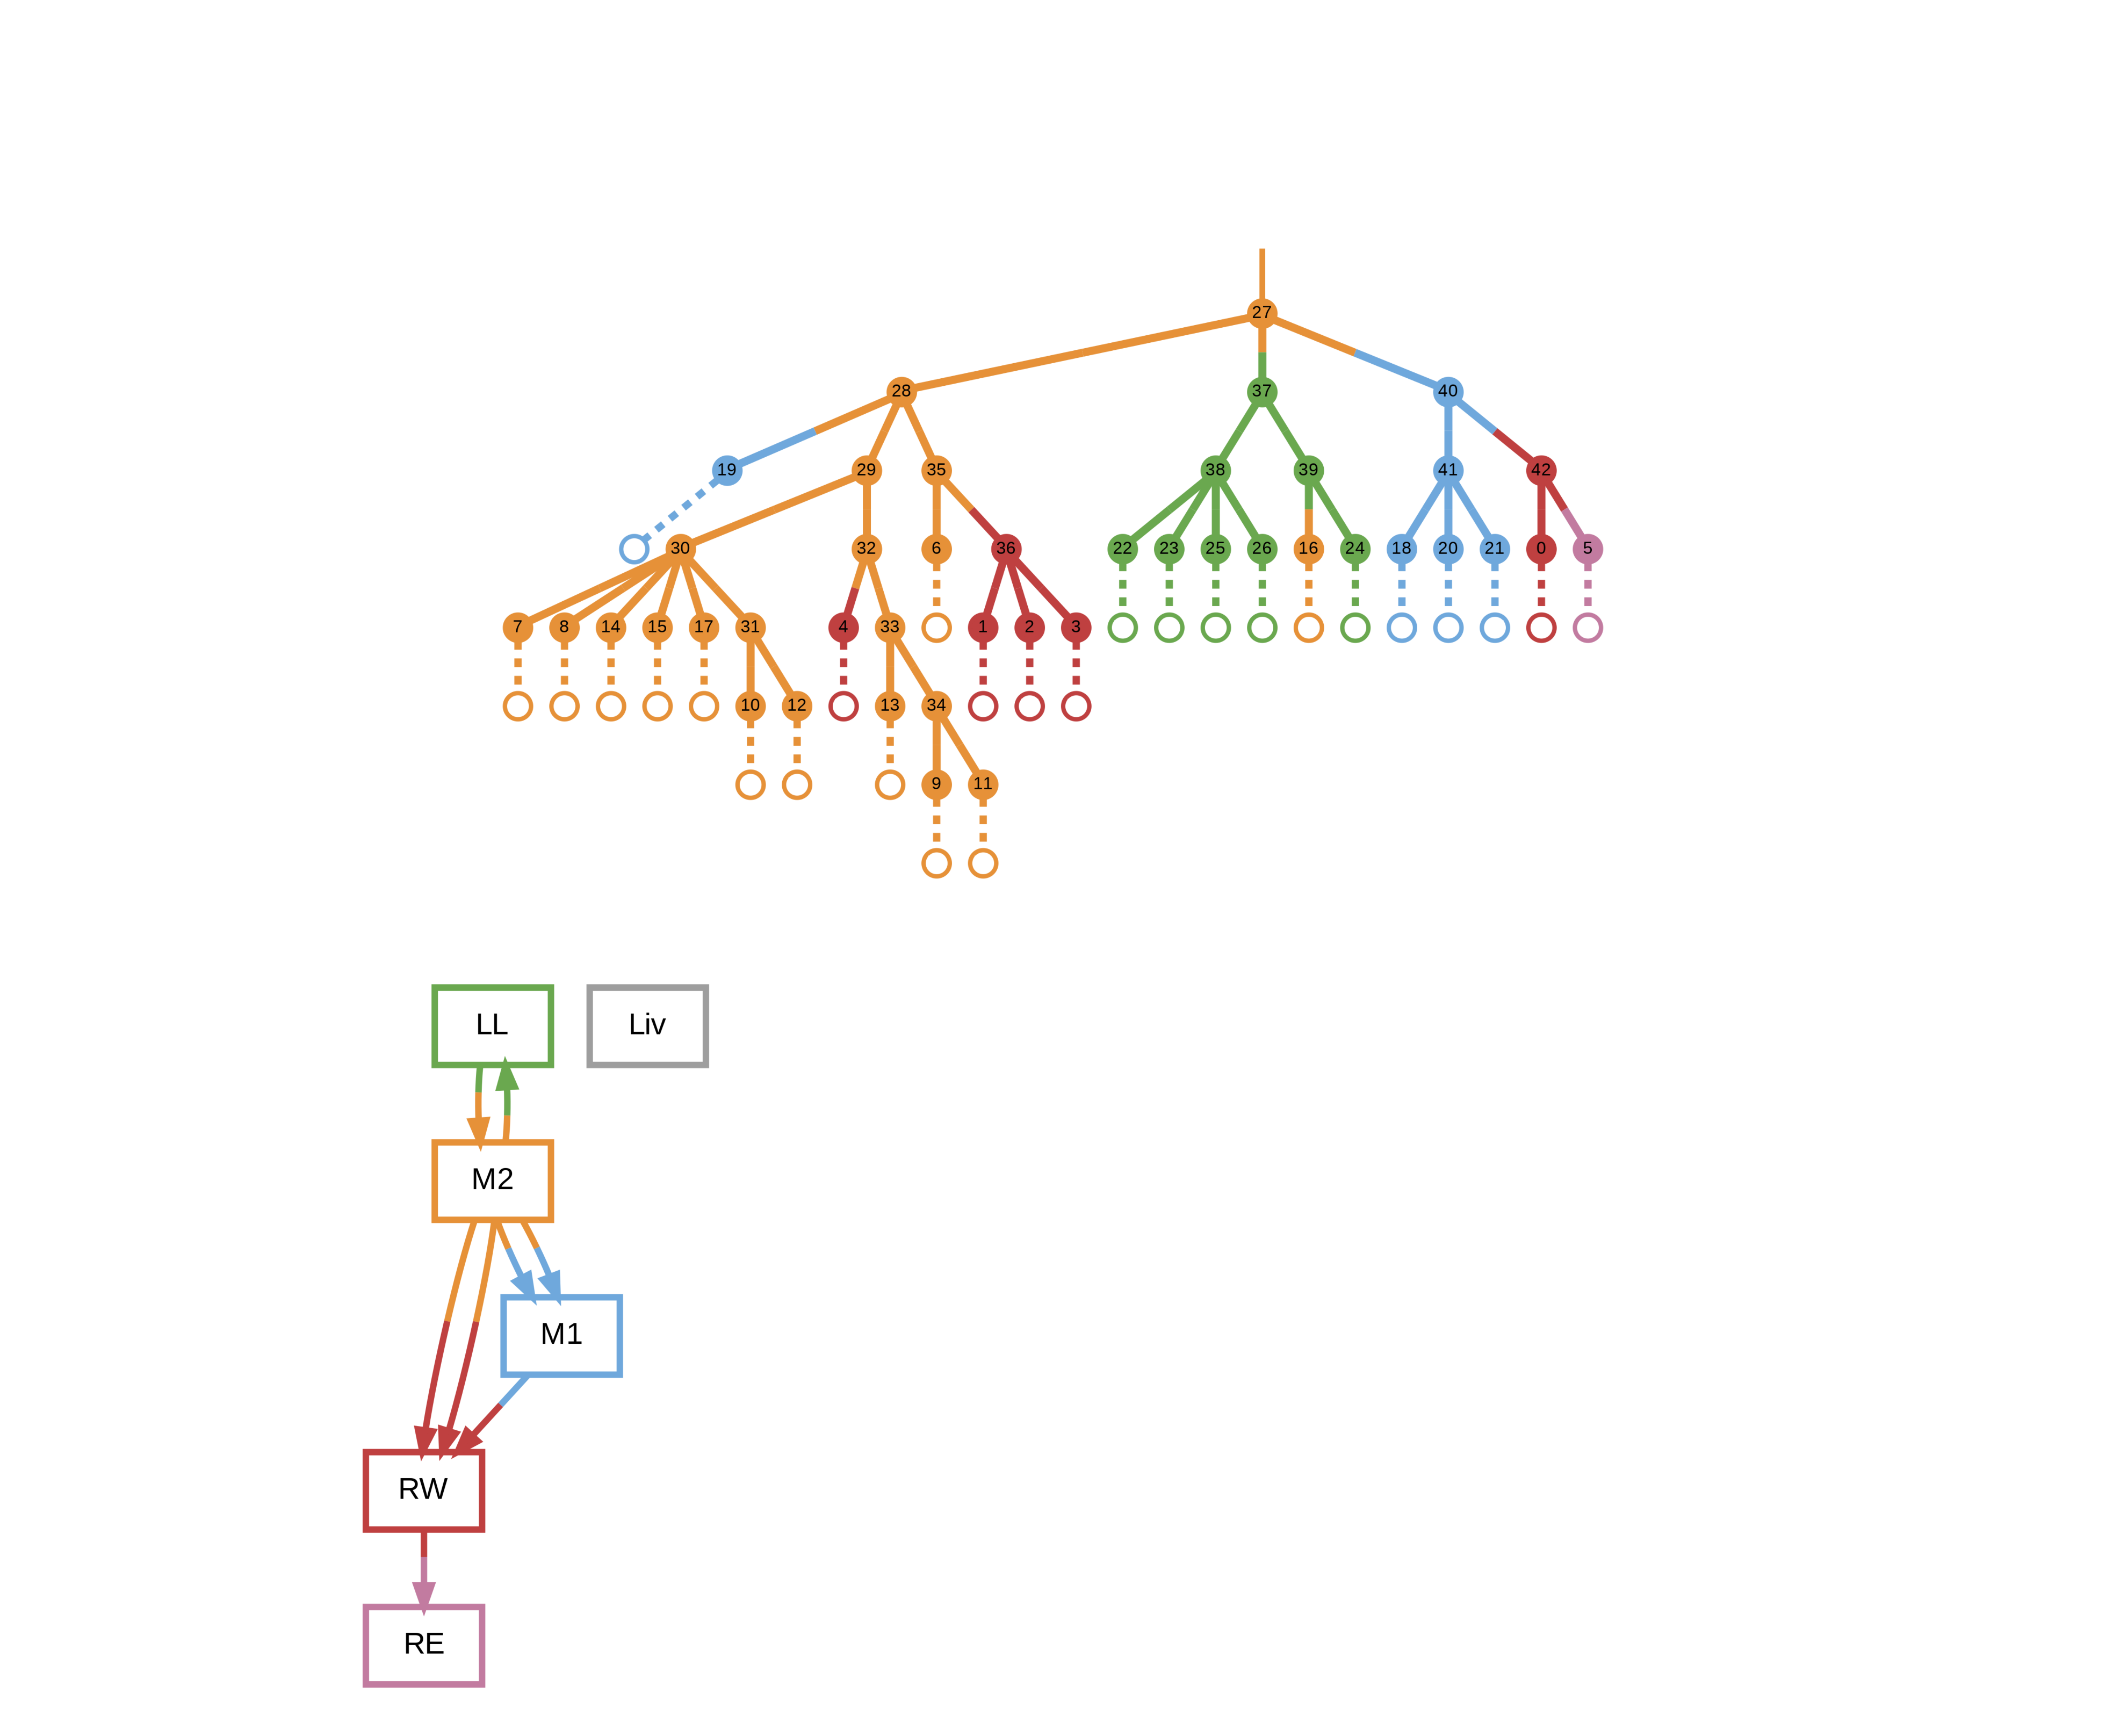

In [3]:
lt_dir = "/data/morrisq/divyak/projects/metient/data/quinn_lt_2021/"
cass_results_dir = os.path.join(lt_dir, "cassiopeia_outputs")

with open(os.path.join(cass_results_dir,'vanilla_greedy_cas_random_min_mig_history.pkl'), 'rb') as f:
    fitch_min_mig_history = pickle.load(f)

clone=99
with open(os.path.join(cass_results_dir,f'{clone}_vanilla_cas_networkx.pkl'), 'rb') as f:
    G = pickle.load(f)
G.remove_node("primary")
print(G)
lt.plot_nx_tree(fitch_min_mig_history[clone], G, f"{clone}_fitch_count_random_history")

### Load migration histories

In [14]:
import gzip

metient_results_dir = os.path.join(lt_dir, "metient_outputs", "2048bs_200runs_05142025_r2")

clones = [int(f[:-len('_LL.pkl.gz')]) for f in os.listdir(metient_results_dir) if f.endswith('_LL.pkl.gz')]
clones = sorted(clones)
print(len(clones), "clones")


def consensus_migration_graph_over_clones(scaled_migration_graphs):
    # Sum all normalized migration graphs with equal weights
    consensus_migrations = torch.zeros_like(scaled_migration_graphs[0])
    for graph in scaled_migration_graphs:
        consensus_migrations += graph
    
    # Normalize by dividing by total sum to make everything sum to 1
    total_sum = consensus_migrations.sum()
    # Handle case where sum is 0 to avoid division by zero
    total_sum = total_sum if total_sum != 0 else 1.0
    consensus_migrations = consensus_migrations / total_sum

    # row_sums = consensus_migrations.sum(dim=1, keepdim=True)
    # # Replace zero sums with ones to avoid division by zero
    # row_sums = row_sums.where(row_sums != 0, torch.tensor(1.0))
    # # Divide each element by its corresponding row sum
    # consensus_migrations = consensus_migrations / row_sums
    return consensus_migrations

with open(os.path.join(cass_results_dir,'vanilla_greedy_cas_unnormalized_tissue_transitions.pkl'), 'rb') as f:
    fitch_tissue_trans_data = pickle.load(f)

with open(os.path.join(cass_results_dir,'vanilla_greedy_cas_min_mig_score.pkl'), 'rb') as f:
    fitch_min_mig_scores = pickle.load(f)

clone_to_metient_tree_met_rate = {}
clone_to_fitch_tree_met_rate = {}
clone_to_metient_min_migration_num = {}

for clone in fitch_min_mig_scores:
    with open(os.path.join(cass_results_dir,f'{clone}_vanilla_cas_networkx.pkl'), 'rb') as f:
        G = pickle.load(f)
    edges = G.number_of_edges()
    clone_to_fitch_tree_met_rate[clone] = fitch_min_mig_scores[clone]/edges

pars_metrics_data = []

met_scaled_migration_graphs = []
fitch_scaled_migration_graphs = []
CLONE_15_MIGRATION_GRAPHS = []
num_first_soln_not_min_mig = 0
for clone in clones:
    print(f"\nclone {clone}")

    _, weighted_scaled_tissue_trans, pars_metrics, mig_graphs = lt.extract_info(metient_results_dir, clone)
    with open(os.path.join(cass_results_dir,f'{clone}_vanilla_cas_networkx.pkl'), 'rb') as f:
        G = pickle.load(f)
    mig_numbers = set()
    for x,metric in enumerate(pars_metrics):
        mig_numbers.add(metric[0])
        if clone == 15:
            CLONE_15_PRIORITY_SOLNS = [0, len(pars_metrics)//2, len(pars_metrics)-1]
            name = f"Solution {x+1}" if x in CLONE_15_PRIORITY_SOLNS else f"All other solutions"
            pars_metrics_data.append([metric[0], metric[1], metric[2],name,])
    edges = G.number_of_edges()
    clone_to_metient_tree_met_rate[clone] = pars_metrics[0][0]/edges
    min_mig = int(min(mig_numbers))
    clone_to_metient_min_migration_num[clone] = min_mig

    # Check if first solution follows tie-breaking structure:
    # 1. Minimizes migrations
    # 2. If tied on migrations, minimizes comigrations
    # 3. If tied on comigrations, minimizes seeding sites
    if min_mig != pars_metrics[0][0] or \
       (min_mig == pars_metrics[0][0] and \
        any(p[0] == min_mig and p[1] < pars_metrics[0][1] for p in pars_metrics[1:])) or \
       (min_mig == pars_metrics[0][0] and \
        any(p[0] == min_mig and p[1] == pars_metrics[0][1] and p[2] < pars_metrics[0][2] for p in pars_metrics[1:])):
        num_first_soln_not_min_mig += 1
    
    met_scaled_migration_graphs.append(weighted_scaled_tissue_trans)
    if clone == 15:
        CLONE_15_MIGRATION_GRAPHS = mig_graphs
    fitch_tissue_trans = lt.extract_scaled_fitch_tissue_trans(fitch_tissue_trans_data, clone)
    fitch_scaled_migration_graphs.append(fitch_tissue_trans)
    pars_metrics_data.reverse()

met_consensus_migrations = consensus_migration_graph_over_clones(met_scaled_migration_graphs)
fitch_consensus_migrations = consensus_migration_graph_over_clones(fitch_scaled_migration_graphs)
print(num_first_soln_not_min_mig)

100 clones

clone 1
75 solutions


/lila/data/morrisq/divyak/projects/metient/metient/util/data_extraction_util.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parents = torch.tensor(parents)[mask]


KeyboardInterrupt: 

In [7]:
def normalize_mig_graph(mig_graph):
    # Get total sum of all elements
    total_sum = mig_graph.sum()
    # If sum is 0, avoid division by zero
    total_sum = total_sum if total_sum != 0 else torch.tensor(1.0)
    # Divide each element by total sum to make everything sum to 1
    normed_tissue_trans = mig_graph / total_sum
    # Zero out small values and those below threshold
    normed_tissue_trans[normed_tissue_trans < 0.01] = 0
    return normed_tissue_trans
print(lt.TISSUE_ORDER)
for x in CLONE_15_PRIORITY_SOLNS:
    print(x)
    normed = normalize_mig_graph(CLONE_15_MIGRATION_GRAPHS[x])
    print(f"Solution {x+1}")
    # print(CLONE_26_MIGRATION_GRAPHS[x])
    print(normed)
    print(pars_metrics_data[x])


['LL', 'RE', 'RW', 'M1', 'M2', 'Liv']
0
Solution 1
tensor([[0.00, 0.00, 0.00, 0.04, 0.04, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.10, 0.10, 0.07, 0.00, 0.43, 0.06],
        [0.00, 0.00, 0.02, 0.10, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00]])
[226, 5, 1, 'Solution 20']
10
Solution 11
tensor([[0.00, 0.07, 0.04, 0.41, 0.32, 0.03],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.02, 0.00, 0.02, 0.00],
        [0.00, 0.00, 0.00, 0.06, 0.00, 0.01],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00]])
[185, 14, 3, 'All other solutions']
19
Solution 20
tensor([[0.00, 0.06, 0.05, 0.42, 0.42, 0.04],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00]])
[124, 29, 3, 'Solution 1'

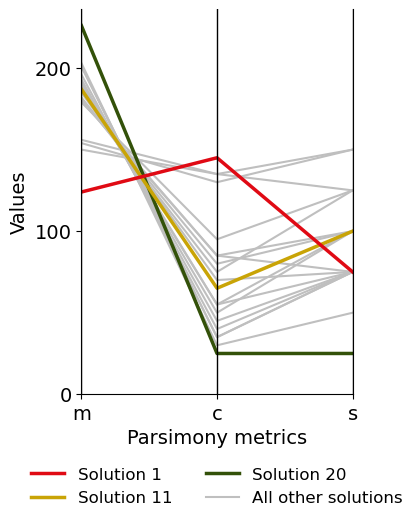

In [8]:
from pandas.plotting import parallel_coordinates
from matplotlib import cm

priority_solns = [f'Solution {x+1}' for x in CLONE_15_PRIORITY_SOLNS]
pars_metrics_df = pd.DataFrame(pars_metrics_data, columns=["Migration #", "Comigration #", "Seeding site #", "Clone", ])
pars_metrics_df["Comigration #"] = pars_metrics_df["Comigration #"]*5

pars_metrics_df["Seeding site #"] = pars_metrics_df["Seeding site #"]*25
non_priority_solns = pars_metrics_df[~pars_metrics_df['Clone'].isin(priority_solns)]
priority_solns_df = pars_metrics_df[pars_metrics_df['Clone'].isin(priority_solns)]

# Reorder the DataFrame so that priority clones are last
pars_metrics_df_ordered = pd.concat([non_priority_solns, priority_solns_df])


colors = ["#bfbfbf", "#324F64", "#AD422B", "#386600"]
colors = ["#bfbfbf","#e00a14","#c9a406", "#335109",]
colors = ["#bfbfbf", "#335109","#c9a406","#e00a14",]

plt.figure(figsize=(3.5,5))
ax = parallel_coordinates(pars_metrics_df_ordered, 'Clone', color=colors, linewidth=1.8)
ax.spines['left'].set_color('black')  # Set the color of the y-axis spine to black
ax.spines['right'].set_color('black')  # Set the color of the y-axis spine to black
ax.spines['bottom'].set_color('black')  # Set the color of the y-axis spine to black

linewidth_mapping = {f'Solution {x+1}': 2.5 for x in CLONE_15_PRIORITY_SOLNS}
linewidth_mapping['All other solutions'] = 1.5

# Iterate over the lines in the plot and update their linewidths based on the hue
for line, label in zip(ax.get_lines(), pars_metrics_df_ordered['Clone']):
    line.set_linewidth(linewidth_mapping[label])

ax.tick_params(axis='y', colors='black')  # Set the color of y-axis ticks and labels to black

plt.xlabel("Parsimony metrics",fontsize=14)
plt.ylabel("Values",fontsize=14)
plt.grid(False)
# Remove the right and top spines (axes)
ax.spines['top'].set_visible(False)

# custom_yticks = [30,40,50,60,80,100,150,200]  # Only show these y-tick positions
# custom_ytick_labels = ['30','40','50','60','80','100','150','200']  # Labels corresponding to the y-tick positions
# plt.yticks(custom_yticks, custom_ytick_labels)
plt.xticks([0,1,2], ["m","c","s"], fontsize=14)
plt.yticks([0,100, 200,], fontsize=14)
handles, labels = plt.gca().get_legend_handles_labels()
desired_order = priority_solns + ['All other solutions']
ordered_handles = [handles[labels.index(label)] for label in desired_order]
ordered_labels = [labels[labels.index(label)] for label in desired_order]
plt.legend(ordered_handles, ordered_labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False, ncol=2, fontsize=12)

plt.savefig(os.path.join(output_dir, f"parallel_coordinates_subset_clones.svg"), dpi=500, bbox_inches='tight',pad_inches=0.1)
plt.show()
plt.close()


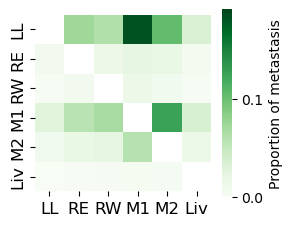

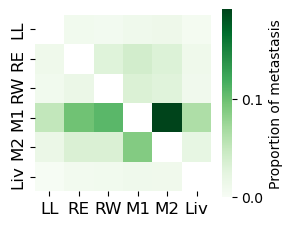

In [9]:
import math
def plot_overall_tissue_transiton(tissue_trans, max_val, method):
    # Overall tissue transition matrix
    tissue_trans = tissue_trans.clone()
    tissue_trans.fill_diagonal_(float('nan'))

    fig = plt.figure(figsize = (3,3))
    rounded_max_val = round(max_val * 20) / 20
    g = sns.heatmap(tissue_trans, cmap="Greens", square=True, vmin=0, vmax=max_val, 
                    cbar=True, cbar_kws={"label": "Proportion of metastasis", "ticks": [0, rounded_max_val/2, rounded_max_val], "shrink": 0.7})
    g.set_xticks([x+0.5 for x in range(len(lt.TISSUE_ORDER))],lt.TISSUE_ORDER, fontsize=12)
    g.set_yticks([x+0.5 for x in range(len(lt.TISSUE_ORDER))],lt.TISSUE_ORDER, fontsize=12)
    plt.subplots_adjust(hspace=0.7, wspace=0.1)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"consensus_migrations_{method}.svg"), dpi=500)
    plt.show()
    plt.close()

max_val = float(max(torch.max(met_consensus_migrations), torch.max(fitch_consensus_migrations)))
print()
plot_overall_tissue_transiton(met_consensus_migrations, max_val, "metient")
plot_overall_tissue_transiton(fitch_consensus_migrations, max_val, "fitch")
   


In [10]:
print(met_consensus_migrations.sum())
print(fitch_consensus_migrations.sum())
# Make copies of original matrices
met_filtered = met_consensus_migrations.clone()
fitch_filtered = fitch_consensus_migrations.clone()
print(lt.TISSUE_ORDER)
# Zero out small values in copies
met_filtered[met_filtered < 0.05] = 0
fitch_filtered[fitch_filtered < 0.05] = 0

met_filtered, fitch_filtered

tensor(1.)
tensor(1.)
['LL', 'RE', 'RW', 'M1', 'M2', 'Liv']


(tensor([[0.00, 0.07, 0.06, 0.18, 0.10, 0.00],
         [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
         [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
         [0.00, 0.06, 0.07, 0.00, 0.13, 0.00],
         [0.00, 0.00, 0.00, 0.06, 0.00, 0.00],
         [0.00, 0.00, 0.00, 0.00, 0.00, 0.00]]),
 tensor([[0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
         [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
         [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
         [0.05, 0.10, 0.11, 0.00, 0.19, 0.06],
         [0.00, 0.00, 0.00, 0.09, 0.00, 0.00],
         [0.00, 0.00, 0.00, 0.00, 0.00, 0.00]]))

In [11]:
pd.set_option('display.max_rows', 10)
meta_df = pd.read_csv("/data/morrisq/divyak/data/quinn_lin_tracing_2021/GSE161363/GSM4905335_meta.5k.tsv", sep="\t")
meta_df['Metient_TreeMetRate'] = meta_df.apply(lambda row: clone_to_metient_tree_met_rate[row['LineageGroup']] if row['LineageGroup'] in clone_to_metient_tree_met_rate else np.nan, axis=1)
meta_df['FitchCount_TreeMetRate'] = meta_df.apply(lambda row: clone_to_fitch_tree_met_rate[row['LineageGroup']]  if row['LineageGroup'] in clone_to_fitch_tree_met_rate else np.nan, axis=1)
meta_df['Metient_MinMigNum'] = meta_df.apply(lambda row: clone_to_metient_min_migration_num[row['LineageGroup']]  if row['LineageGroup'] in clone_to_metient_min_migration_num else np.nan, axis=1)
meta_df['FitchCount_MinMigNum'] = meta_df.apply(lambda row: fitch_min_mig_scores[row['LineageGroup']]  if row['LineageGroup'] in fitch_min_mig_scores else np.nan, axis=1)

meta_df

,cellBC,LineageGroup,sampleID,TS_UMI,NUM_INTBC,Sample2,StaticMetScore,TissueDispersion,TreeMetRate,scTreeMetRate,Metient_TreeMetRate,FitchCount_TreeMetRate,Metient_MinMigNum,FitchCount_MinMigNum
0,RW.TTTGTCATCAGCTCGG-1,24,RW,44,6,RL,0.605,0.605,0.125,0.114,0.240,0.237,87.000,86
1,RW.TTTGTCAGTTAGAACA-1,39,RW,186,5,RL,NaN,NaN,NaN,NaN,0.007,0.000,1.000,0
2,RW.TTTGTCAGTGTTTGTG-1,2,RW,158,4,RL,0.835,0.835,0.116,0.134,0.227,0.227,"2,929.000",2928
3,RW.TTTGTCAGTGACGCCT-1,2,RW,195,10,RL,0.835,0.835,0.116,0.073,0.227,0.227,"2,929.000",2928
4,RW.TTTGTCAGTACCGTTA-1,92,RW,166,7,RL,0.459,0.459,0.051,0.013,0.136,0.114,6.000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40964,LL.AAACGGGTCGTTTAGG-1,4,LL,82,11,LL,0.763,0.763,0.058,0.015,0.128,0.128,224.000,223
40965,LL.AAACGGGGTGTTAAGA-1,29,LL,143,10,LL,0.050,0.050,0.000,0.000,0.000,0.000,0.000,0
40966,LL.AAACGGGGTCTTGATG-1,1,LL,168,8,LL,0.779,0.779,0.169,0.242,0.278,0.278,"4,306.000",4305
40967,LL.AAACCTGTCAAGGTAA-1,1,LL,81,6,LL,0.779,0.779,0.169,0.206,0.278,0.278,"4,306.000",4305


In [12]:
pd.set_option('display.max_rows', None)
mig_df = meta_df[['LineageGroup','Metient_MinMigNum','FitchCount_MinMigNum' ]].drop_duplicates()
mig_df = mig_df.dropna()
mig_df['Found_MinMigNum'] = mig_df.apply(lambda row: (row['Metient_MinMigNum'] - row['FitchCount_MinMigNum']) <= 1, axis=1 ) 

print(mig_df['Found_MinMigNum'].value_counts())
mig_df

Found_MinMigNum
True    99
Name: count, dtype: int64


,LineageGroup,Metient_MinMigNum,FitchCount_MinMigNum,Found_MinMigNum
0,24,87.000,86,True
1,39,1.000,0,True
2,2,"2,929.000",2928,True
4,92,6.000,5,True
5,1,"4,306.000",4305,True
10,13,213.000,212,True
13,9,269.000,268,True
15,3,124.000,123,True
23,8,308.000,307,True
25,4,224.000,223,True


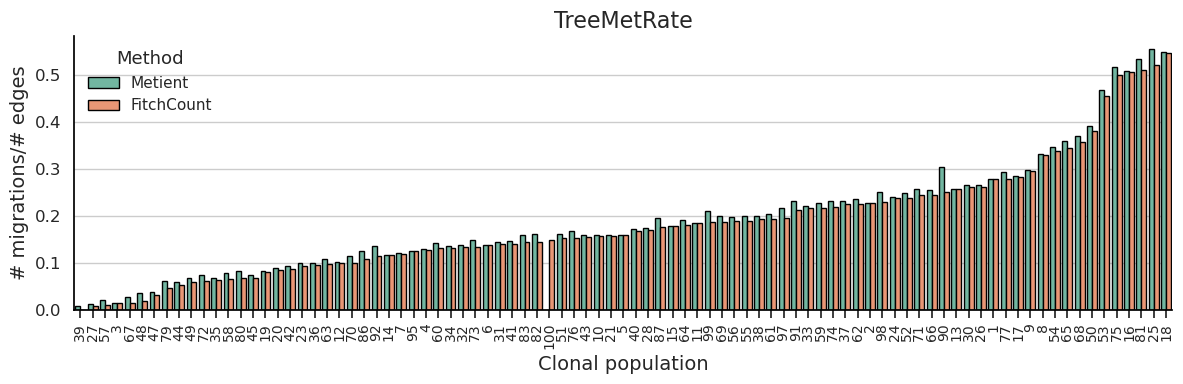

In [13]:
# Melt the DataFrame to have one column for the 'Rate' and one for the 'Method'
meta_df['FitchCount'] = meta_df['FitchCount_TreeMetRate']
meta_df['Metient'] = meta_df['Metient_TreeMetRate']

df_melted = meta_df.melt(id_vars='LineageGroup', 
                    value_vars=['Metient','FitchCount'], 
                    var_name='Method', 
                    value_name='Rate')

# Create a grouped bar plot using seaborn
sns.set(style="whitegrid", palette="muted")  # Set an aesthetic style and palette

# Order by TreeMetRate
df_unique = meta_df.drop_duplicates(subset='FitchCount')
df_sorted = df_unique.sort_values(by='FitchCount_TreeMetRate', ascending=True)
order = df_sorted['LineageGroup'].tolist()

plt.figure(figsize=(12, 4))
sns.barplot(data=df_melted, x='LineageGroup', y='Rate', hue='Method', 
            palette='Set2', edgecolor='black', ci=None, order=order)

# Customize the plot aesthetics
plt.title('TreeMetRate', fontsize=16)
plt.xlabel('Clonal population', fontsize=14)
plt.ylabel('# migrations/# edges', fontsize=14)
plt.xticks(fontsize=10,rotation=90)
plt.yticks(fontsize=12)
plt.gca().xaxis.set_ticks_position('bottom')
for x in ['top','right','left','bottom']:
    plt.gca().spines[x].set_color('black')

# Remove top and right spines for aesthetics
sns.despine()

# Add a legend
plt.legend(title='Method', title_fontsize='13', loc='upper left', frameon=False)

plt.tight_layout()  # Adjust layout for better fit

plt.savefig(os.path.join(output_dir, f'tree_met_rate_comparison.png'), dpi=600, bbox_inches='tight')

plt.show()

plt.close()

